In [1]:
### Plotting the analytic solution G(t, U, iw_n) and G(t(U), U, iw_n)
import numpy as np
import matplotlib.pyplot as plt
import analytic_solution as AS
# import utilities_1d as ut_1d

In [2]:
beta = 50.0
Ntau = 401
Ns = 2
Nw = 20
Mat_fre = (2*np.linspace(0, Nw-1, Nw)+1)*np.pi/beta
wn = np.append(-np.flip(Mat_fre),Mat_fre)   # w_n = (2n+1)*pi/beta

In [3]:
t_values_ED = np.linspace(0.001, 2, 100)
Gij_iwn_exact = np.zeros((len(t_values_ED), wn.size, Ns, Ns), dtype ='complex')
U = 1
for u in range(t_values_ED.size):
    Gij_iwn_exact[u] = AS.G_analytic(t_values_ED[u], wn, U, beta/t_values_ED[u])

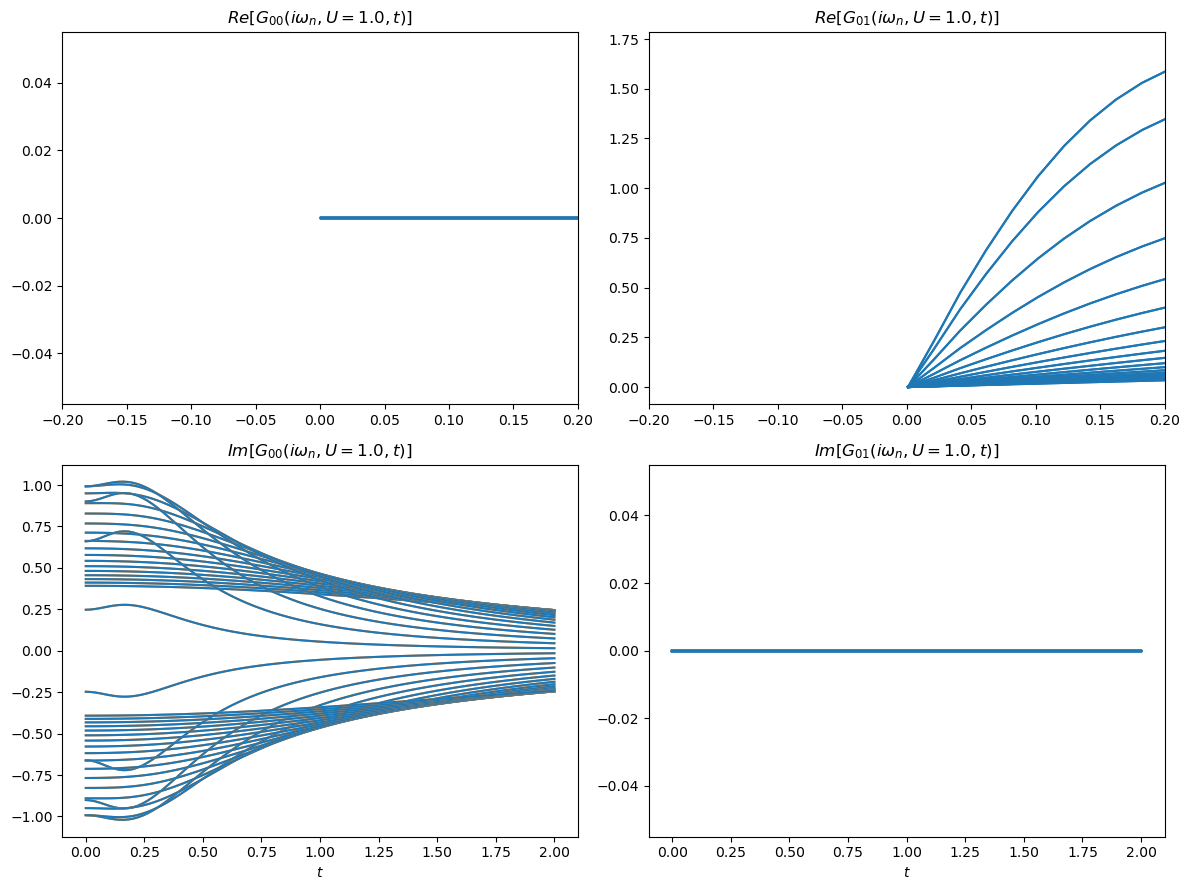

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=False, sharey=False)
(ax11, ax12), (ax21, ax22) = axes

# (1,1) — like your figure(1)
for i in range(wn.size):
    ax11.plot(t_values_ED, Gij_iwn_exact[:, i, 0, 0 ].real, 'C0')
ax11.set_title(r'$Re[G_{00}(i\omega_n,U=%.1f, t)]$'%(U))
ax11.set_xlim([-0.2,0.2])
# (1,2) — like your figure(2)
for i in range(wn.size):
    ax12.plot(t_values_ED, Gij_iwn_exact[:, i, 0,1 ].real, 'C0')
ax12.set_xlim([-0.2,0.2])
ax12.set_title(r'$Re[G_{01}(i\omega_n,U=%.1f, t)]$'%(U))

# (2,1) — like your figure(3)
for i in range(wn.size):
    ax21.plot(t_values_ED, Gij_iwn_exact[:, i, 0, 0 ].imag, 'C1')
    ax21.plot(t_values_ED, Gij_iwn_exact[:, i, 0, 0 ].imag, 'C0')
ax21.set_xlabel(r'$t$')
ax21.set_title(r'$Im[G_{00}(i\omega_n,U=%.1f, t)]$'%(U))

# (2,2) — like your figure(4)
for i in range(wn.size):
    ax22.plot(t_values_ED, Gij_iwn_exact[:, i, 0, 1 ].imag, 'C0')
ax22.set_xlabel(r'$t$')
ax22.set_title(r'$Im[G_{01}(i\omega_n,U=%.1f, t)]$'%(U))

# Optional: remove duplicate y-labels on the right column
for ax in (ax12, ax22):
    ax.set_ylabel('')

fig.tight_layout()
plt.show()